# **Breast Histopathology Images Dataset (Kaggle)**

"Histopathology is the gold standard for cancer diagnosis, but it’s a high-dimensional needle-in-a-haystack problem. This notebook leverages Convolutional Neural Networks (CNNs)—specifically [mention architecture, e.g., ResNet/DenseNet]—to crack the code of Invasive Ductal Carcinoma (IDC) classification.
We will dive into over 277k image patches, focusing on Metastatic Cancer Detection by learning subtle textural and structural features that define malignant tissue. Let’s train our model to see what’s invisible to the naked eye."

![alt text](download.jpg)

## **Import Libraries**

In [ ]:
import os
import cv2
from glob import glob
import math
import numpy as np
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.callbacks import ReduceLROnPlateau

import tf2onnx
import onnx

## **Load Data**

In [62]:
base_path = '../input/datasets/paultimothymooney/breast-histopathology-images/IDC_regular_ps50_idx5/'
all_images = glob(os.path.join(base_path, "*/*/*.png"), recursive=True)

# Parse labels from the filename (e.g., ...class0.png)
data = pd.DataFrame({
    'path': all_images,
    'image_name': [os.path.basename(x) for x in all_images],
    'label': [x[-5] for x in all_images]
})

In [63]:
len(data)

277524

In [64]:
data.head()

,path,image_name,label
0,../input/datasets/paultimothymooney/breast-his...,10295_idx5_x1351_y1101_class0.png,0
1,../input/datasets/paultimothymooney/breast-his...,10295_idx5_x1501_y501_class0.png,0
2,../input/datasets/paultimothymooney/breast-his...,10295_idx5_x1501_y1101_class0.png,0
3,../input/datasets/paultimothymooney/breast-his...,10295_idx5_x451_y901_class0.png,0
4,../input/datasets/paultimothymooney/breast-his...,10295_idx5_x801_y451_class0.png,0


In [65]:
def extract_patient_id(x):
    # split into a list
    a = x.split('_')
    patient_id = a[0]
    
    return patient_id
data['patient_id'] = data['image_name'].apply(extract_patient_id)
data.head()

,path,image_name,label,patient_id
0,../input/datasets/paultimothymooney/breast-his...,10295_idx5_x1351_y1101_class0.png,0,10295
1,../input/datasets/paultimothymooney/breast-his...,10295_idx5_x1501_y501_class0.png,0,10295
2,../input/datasets/paultimothymooney/breast-his...,10295_idx5_x1501_y1101_class0.png,0,10295
3,../input/datasets/paultimothymooney/breast-his...,10295_idx5_x451_y901_class0.png,0,10295
4,../input/datasets/paultimothymooney/breast-his...,10295_idx5_x801_y451_class0.png,0,10295


In [66]:
data['label'].value_counts()

label
0    198738
1     78786
Name: count, dtype: int64

## **Exploratory Data Analysis**

### Healthy Specimen

In [67]:
# Sample 50 images from healthy class for visualization
healthy_samples = data[data['label'] == '0'].sample(50)

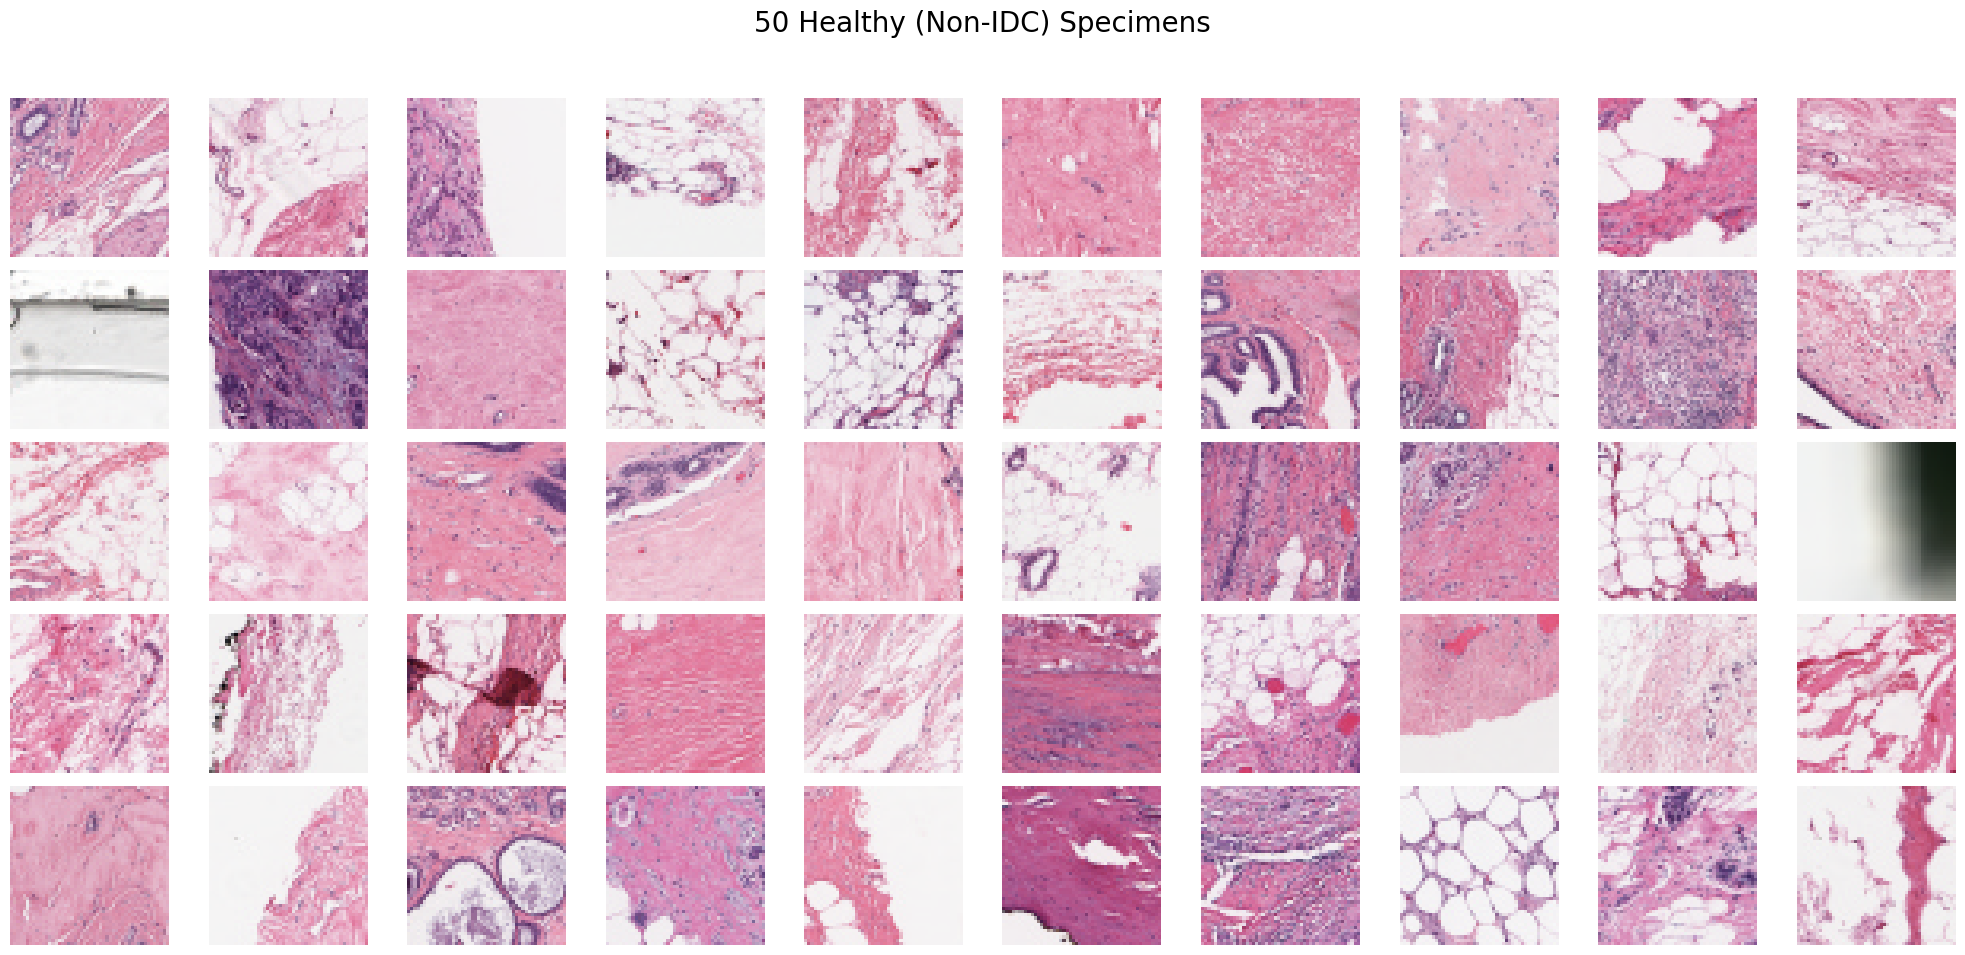

In [68]:
# Plotting
plt.figure(figsize=(20, 10))
plt.suptitle('50 Healthy (Non-IDC) Specimens', fontsize=20)

for i, path in enumerate(healthy_samples['path']):
    plt.subplot(5, 10, i + 1)
    
    # Load and convert from BGR (OpenCV default) to RGB
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(img)
    plt.axis('off')
    # Optional: show image name/index
    # plt.title(f"H_{i}", fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Cancer Specimen

In [69]:
# Sample 50 images from IDC class for visualization
idc_samples = data[data['label'] == '1'].sample(50)

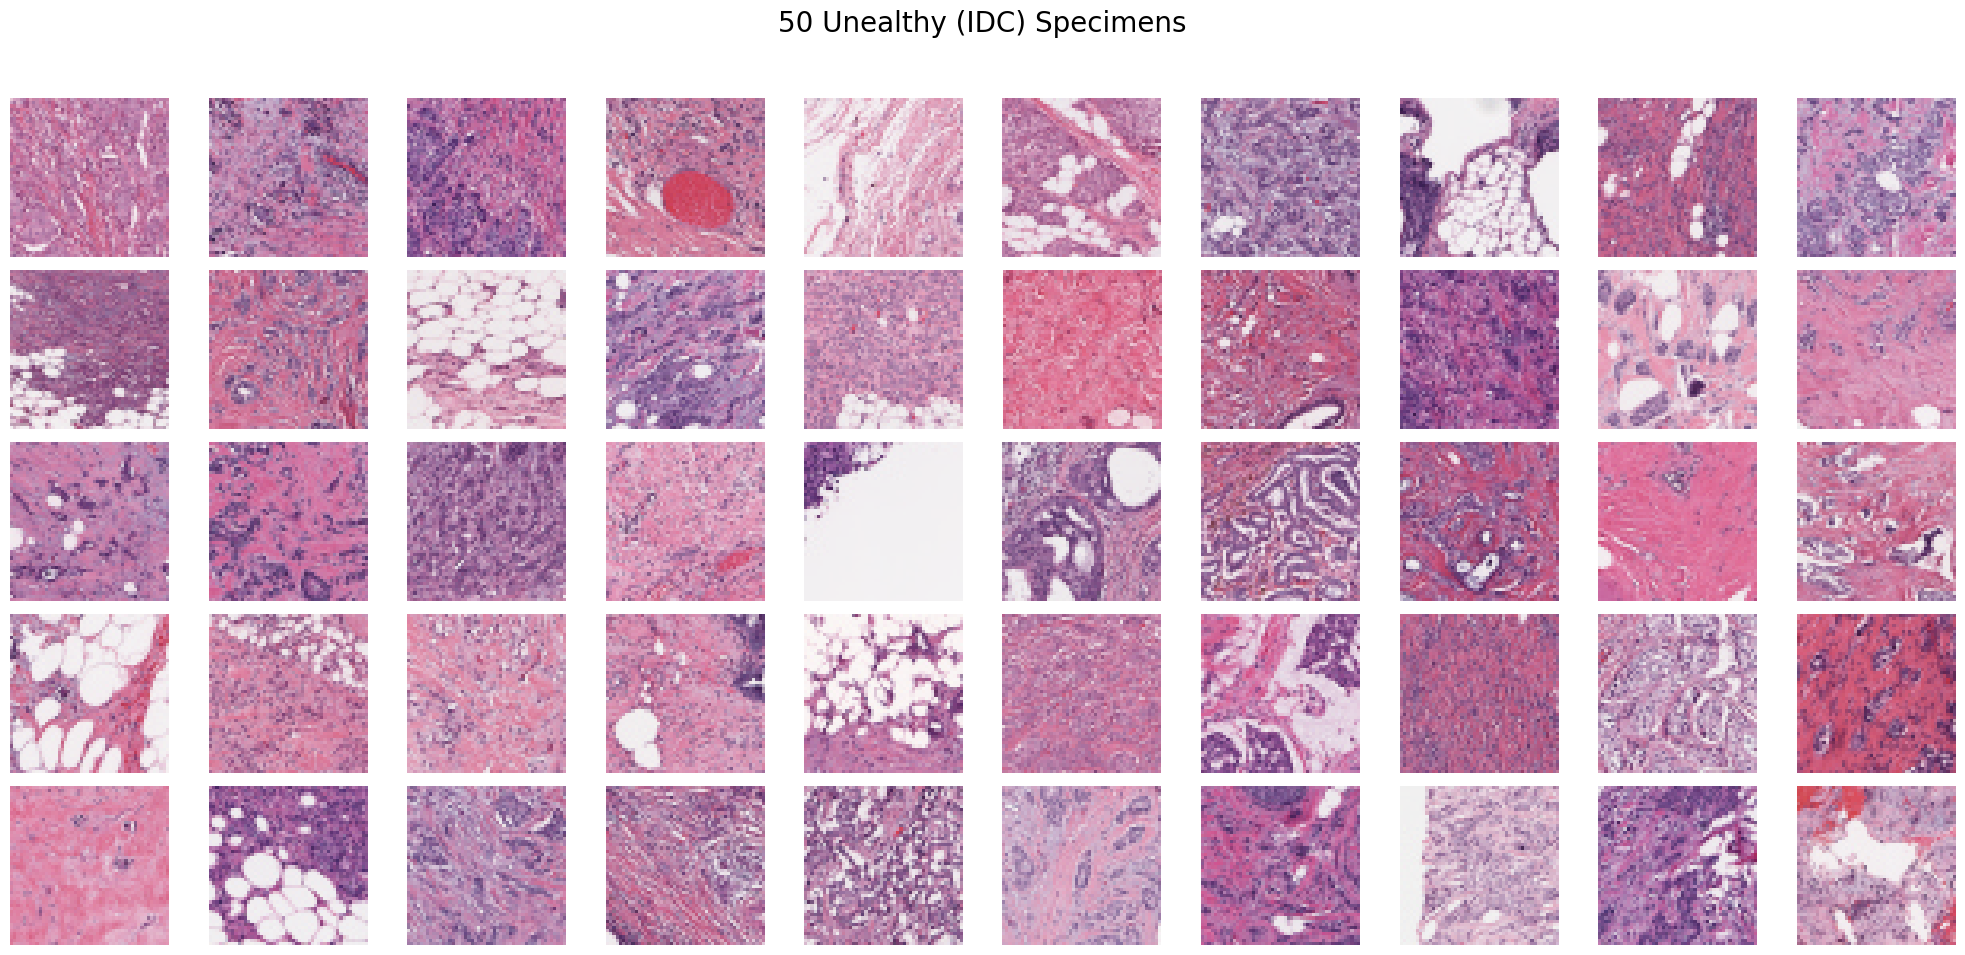

In [70]:
# Plotting
plt.figure(figsize=(20, 10))
plt.suptitle('50 Unealthy (IDC) Specimens', fontsize=20)

for i, path in enumerate(idc_samples['path']):
    plt.subplot(5, 10, i + 1)
    
    # Load and convert from BGR (OpenCV default) to RGB
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(img)
    plt.axis('off')
    # Optional: show image name/index
    # plt.title(f"H_{i}", fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Healthy specimen are light pink while cancer specimen are darker and more violet colored.

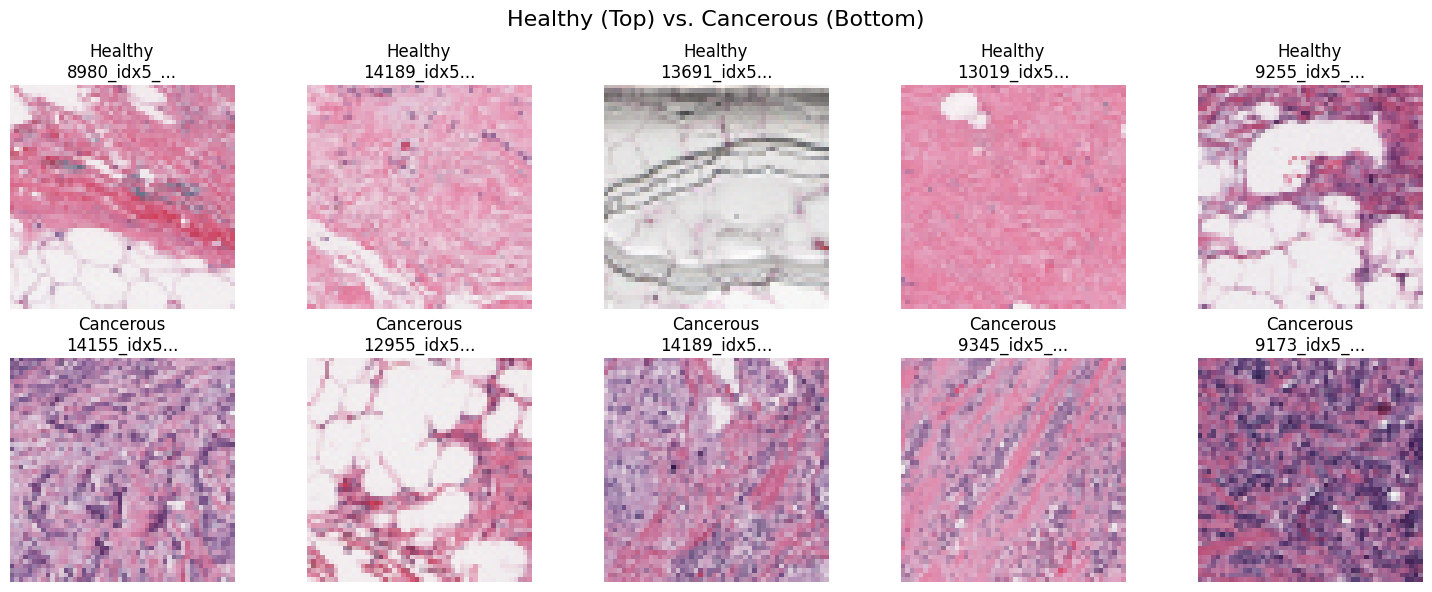

In [71]:
def plot_comparison(df, n=5):
    # Sample n images from each class
    healthy = df[df['label'] == '0'].sample(n, random_state=42)
    cancerous = df[df['label'] == '1'].sample(n, random_state=42)

    fig, axes = plt.subplots(2, n, figsize=(15, 6))
    fig.suptitle('Healthy (Top) vs. Cancerous (Bottom)', fontsize=16)

    for i in range(n):
        # Plot Healthy Row
        img_h = cv2.imread(healthy.iloc[i]['path'])
        img_h = cv2.cvtColor(img_h, cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img_h)
        axes[0, i].set_title(f"Healthy\n{healthy.iloc[i]['image_name'][:10]}...")
        axes[0, i].axis('off')

        # Plot Cancerous Row
        img_c = cv2.imread(cancerous.iloc[i]['path'])
        img_c = cv2.cvtColor(img_c, cv2.COLOR_BGR2RGB)
        axes[1, i].imshow(img_c)
        axes[1, i].set_title(f"Cancerous\n{cancerous.iloc[i]['image_name'][:10]}...")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Run the function
plot_comparison(data, n=5)

### Healthy vs. Cancerous (Class Balance)

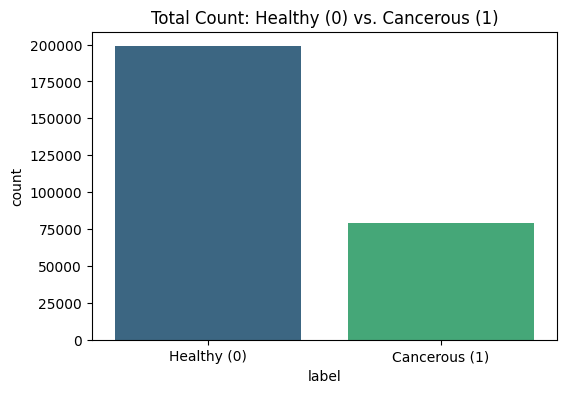

label
0    71.611104
1    28.388896
Name: proportion, dtype: float64


In [72]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=data, hue='label', palette='viridis', legend=False)
plt.title('Total Count: Healthy (0) vs. Cancerous (1)')
plt.xticks(ticks=[0, 1], labels=['Healthy (0)', 'Cancerous (1)'])
plt.show()

print(data['label'].value_counts(normalize=True) * 100)

### Patches per Patient

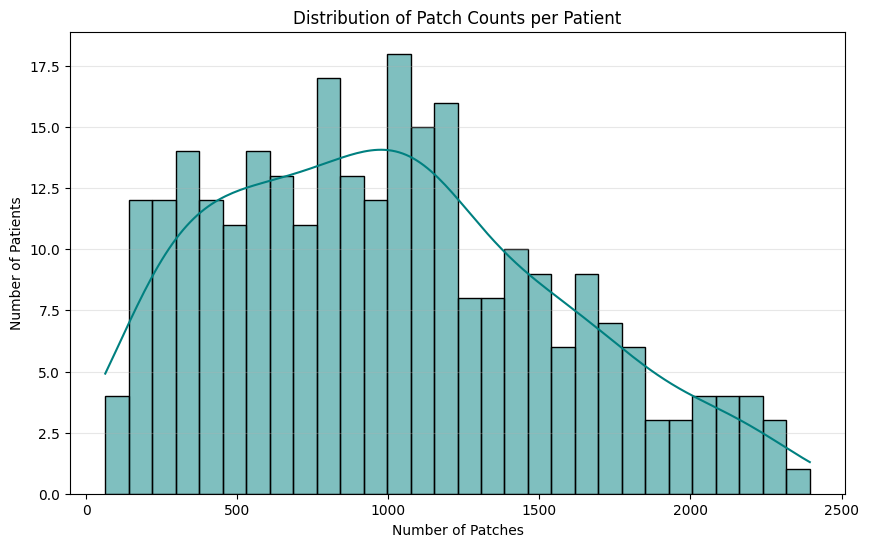

Average patches per patient: 994.71


In [73]:
plt.figure(figsize=(10, 6))

# Using histplot with a Kernel Density Estimate (KDE) curve
sns.histplot(patches_per_patient, kde=True, color='teal', bins=30)

plt.title('Distribution of Patch Counts per Patient')
plt.xlabel('Number of Patches')
plt.ylabel('Number of Patients')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Average patches per patient: {patches_per_patient.mean():.2f}")

### Cancer Percentage per Patient

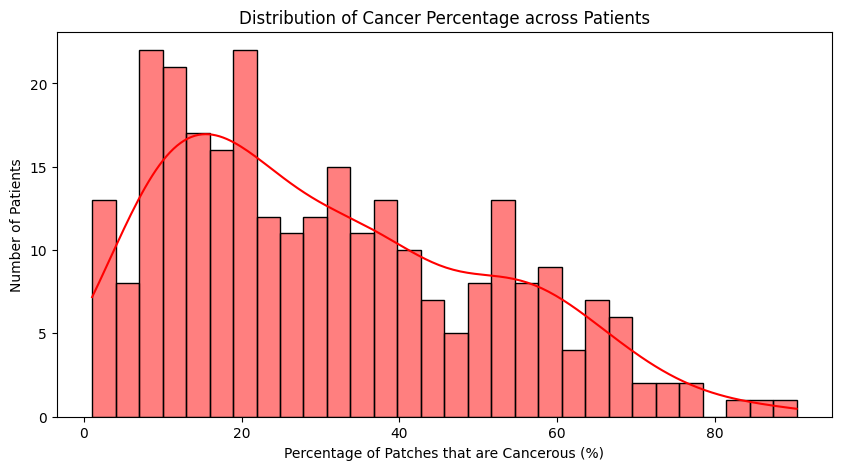

In [74]:
# Calculate mean of labels per patient (since 1=cancer, mean = percentage)
data['label'] = data['label'].astype(int)
cancer_perc = data.groupby('patient_id')['label'].mean() * 100

plt.figure(figsize=(10, 5))
sns.histplot(cancer_perc, bins=30, kde=True, color='red')
plt.title('Distribution of Cancer Percentage across Patients')
plt.xlabel('Percentage of Patches that are Cancerous (%)')
plt.ylabel('Number of Patients')
plt.show()

### Distribution of Patches in each Mammogram

In [75]:
def preprocess_breast_data(df):
    # Extract Coordinates (X and Y) from filenames
    # Pattern: ..._x1351_y1101_...
    df['x'] = df['path'].apply(lambda x: int(x.split('_x')[-1].split('_')[0]))
    df['y'] = df['path'].apply(lambda x: int(x.split('_y')[-1].split('_')[0]))
    
    return df

In [76]:
def plot_multiple_patients(df, num_patients=6, columns=3):
    """Plots the distribution of patches for a random sample of patients in a grid."""
    # Get a random list of patient IDs
    unique_patients = df['patient_id'].unique()
    sampled_ids = pd.Series(unique_patients).sample(num_patients).values
    
    rows = math.ceil(num_patients / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(columns * 5, rows * 5))
    axes = axes.flatten() # Flatten to 1D for easy indexing

    for i, p_id in enumerate(sampled_ids):
        p_df = df[df['patient_id'] == p_id]
        
        # Plot using scatter
        scatter = axes[i].scatter(
            p_df['x'], p_df['y'], 
            c=p_df['label'], 
            cmap='coolwarm', 
            s=5, alpha=0.5, marker='s'
        )
        
        axes[i].set_title(f"Patient {p_id}\nIDC%: {p_df['label'].mean()*100:.1f}%")
        axes[i].invert_yaxis()
        axes[i].axis('off') # Hide axes for a cleaner "slice" look

    # Remove any unused subplot slots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


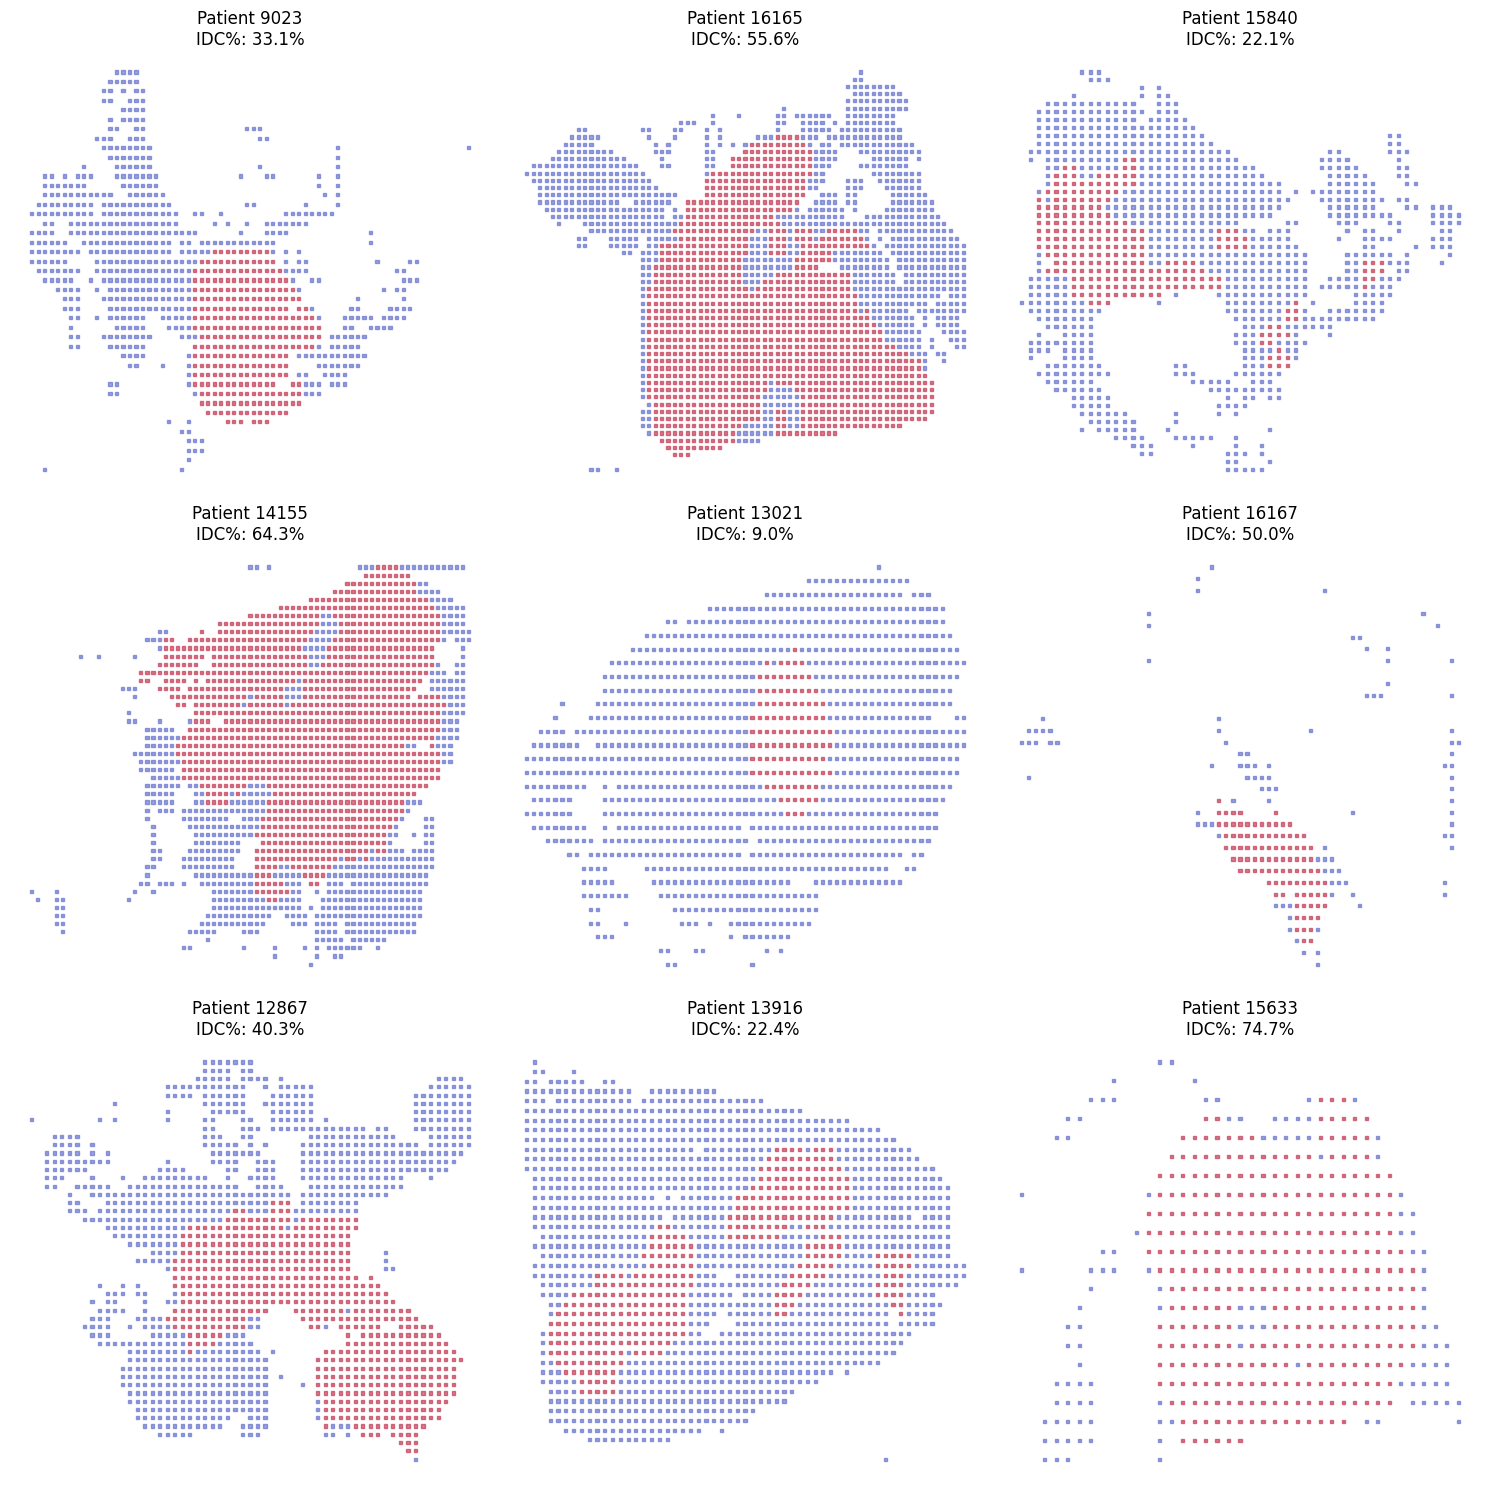

In [77]:
data = preprocess_breast_data(data)
plot_multiple_patients(data, num_patients=9, columns=3)

We see a large variation in the concentration of cells.
Sometimes we don't have the full tissue information.

### Filter out patients with few patches

In [78]:
def filter_low_patch_patients(df, min_patches=100):
    """Removes patients with fewer than min_patches from the dataset."""
    # Count patches per patient
    counts = df['patient_id'].value_counts()
    
    # Identify IDs that meet the threshold
    keep_ids = counts[counts >= min_patches].index
    
    # Filter DataFrame
    filtered_df = df[df['patient_id'].isin(keep_ids)].copy()
    
    # Print Summary
    removed_count = len(counts) - len(keep_ids)
    print(f"Original Patient Count: {len(counts)}")
    print(f"Removed {removed_count} patients with < {min_patches} patches.")
    print(f"Remaining Patient Count: {len(keep_ids)}")
    print(f"Remaining Total Patches: {len(filtered_df)}")
    
    return filtered_df

# Apply the filter
data = filter_low_patch_patients(data, min_patches=100)


Original Patient Count: 279
Removed 2 patients with < 100 patches.
Remaining Patient Count: 277
Remaining Total Patches: 277367


## Split Data Into Train and Test

To prevent Data Leakage, we must split the data by patient_id. If we simply use a random split, patches from the same patient (sharing the same tissue texture and lighting) would appear in both sets, causing the model to "memorize" patients rather than learning "cancer features."

In [79]:
def split_data_by_patient(df, test_size=0.2):
    """Splits the dataframe into train and test sets based on Patient ID."""
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=42)
    
    # Extract indices for the split
    train_idx, test_idx = next(gss.split(df, groups=df['patient_id']))
    
    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()
    
    # Verification
    print(f"Total Patients: {df['patient_id'].nunique()}")
    print(f"Train Patients: {train_df['patient_id'].nunique()} | Patches: {len(train_df)}")
    print(f"Test Patients: {test_df['patient_id'].nunique()} | Patches: {len(test_df)}")
    
    # Check for leakage (should be empty set)
    overlap = set(train_df['patient_id']) & set(test_df['patient_id'])
    print(f"Patient overlap check: {overlap}")
    
    return train_df, test_df

In [80]:
train_df, test_df = split_data_by_patient(data, test_size=0.2)

Total Patients: 277
Train Patients: 221 | Patches: 217383
Test Patients: 56 | Patches: 59984
Patient overlap check: set()


In [81]:
print("\nTrain Class Balance (%):")
print(train_df['label'].value_counts(normalize=True) * 100)

print("\nTest Class Balance (%):")
print(test_df['label'].value_counts(normalize=True) * 100)


Train Class Balance (%):
label
0    71.858425
1    28.141575
Name: proportion, dtype: float64

Test Class Balance (%):
label
0    70.843892
1    29.156108
Name: proportion, dtype: float64


In [82]:
train_df.head()

,path,image_name,label,patient_id,x,y
0,../input/datasets/paultimothymooney/breast-his...,10295_idx5_x1351_y1101_class0.png,0,10295,1351,1101
1,../input/datasets/paultimothymooney/breast-his...,10295_idx5_x1501_y501_class0.png,0,10295,1501,501
2,../input/datasets/paultimothymooney/breast-his...,10295_idx5_x1501_y1101_class0.png,0,10295,1501,1101
3,../input/datasets/paultimothymooney/breast-his...,10295_idx5_x451_y901_class0.png,0,10295,451,901
4,../input/datasets/paultimothymooney/breast-his...,10295_idx5_x801_y451_class0.png,0,10295,801,451


In [83]:
train_df['label_str'] = train_df['label'].astype(str)
test_df['label_str'] = test_df['label'].astype(str)

## **Setup Data Generators**

In [ ]:
# 1. Configuration for Training

# Use the model's specific preprocessing function instead of rescale=1./255
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 2. Configuration for Testing (ONLY Rescaling)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 3. Create the Training Stream

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='label_str',
    target_size=(75,75), # UPSAMPLE HERE
    batch_size=32,          # InceptionResNetV2 is heavy; start with 32
    class_mode='binary'
)

# 4. Create the Test/Validation Stream

# Create the Test/Validation Stream
test_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label_str',
    target_size=(75,75), 
    batch_size=32,
    class_mode='binary',
    shuffle=False  # IMPORTANT: Keep False for evaluation
)

KeyboardInterrupt: 

## **Build InceptionResNetV2 Model**

In [ ]:
# 1. Load Pre-trained Base
base_model = InceptionResNetV2(
    weights='imagenet', 
    include_top=False,      # Remove the ImageNet classifier head
    input_shape=(139, 139, 3)
)

# 2. Freeze Base Layers
base_model.trainable = False

# 3. Add Custom Classification Head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') # Binary output
])

# 4. Compile the Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

model.summary()

Since the dataset is huge, we don't train for too many epochs initially. We use callbacks to save best model and stop early if it stops improving.

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_idc_model.h5', save_best_only=True)
]

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    callbacks=callbacks,
    workers=4,                   # Kaggle typically allows 2-4 workers
    use_multiprocessing=True     # Uses CPU cores in parallel for resizing
)

### Fine-Tuning

In [ ]:
# 1. Unfreeze the base model
base_model.trainable = True

# Freeze Batch Normalization layers to prevent them from updating during fine-tuning
for layer in base_model.layers:
    if "BatchNormalization" in layer.__class__.__name__:
        layer.trainable = False

# We only want to train from layer 600 onwards
fine_tune_at = 600 

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 2. Re-compile with a VERY small learning rate, higher rates will destroy the pre-trained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [ ]:
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=2, 
    min_lr=1e-7
)

# Continue training for a few more epochs
fine_tune_history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5, # Fine-tuning usually needs fewer epochs
    callbacks=[callbacks, lr_reducer],
    workers=4,                   # Kaggle typically allows 2-4 workers
    use_multiprocessing=True     # Uses CPU cores in parallel for resizing
)

## **Predictions**

In [ ]:
# 1. Get predictions (probabilities)
preds = model.predict(test_generator)

# 2. Convert probabilities to binary classes (0 or 1) using 0.5 threshold
y_pred = (preds > 0.5).astype(int).flatten()

# 3. Get true labels from the generator
y_true = test_generator.classes

## **Model Evaluation**

### Confusion Matrix

In [ ]:
def plot_cm(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Healthy', 'IDC'], 
                yticklabels=['Healthy', 'IDC'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

plot_cm(y_true, y_pred)

### Classification Report

In [ ]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Healthy (0)', 'IDC (1)']))

### Patient Tissue Visualization

In [ ]:
def plot_actual_vs_predicted(df, patient_id):
    """Plots side-by-side maps of Actual labels vs Model Predictions."""
    patient_df = df[df['patient_id'] == str(patient_id)]
    
    if 'model_prediction' not in patient_df.columns:
        print("Error: Run predictions and add them to the dataframe first!")
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    # 1. Ground Truth (Actual)
    ax1.scatter(patient_df['x'], patient_df['y'], c=patient_df['label'], 
                cmap='coolwarm', s=20, marker='s', alpha=0.7)
    ax1.set_title(f'Actual Labels: Patient {patient_id}')
    ax1.invert_yaxis()
    ax1.axis('off')

    # 2. Model Prediction
    ax2.scatter(patient_df['x'], patient_df['y'], c=patient_df['model_prediction'], 
                cmap='coolwarm', s=20, marker='s', alpha=0.7)
    ax2.set_title(f'Model Predictions: Patient {patient_id}')
    ax2.invert_yaxis()
    ax2.axis('off')

    plt.suptitle(f"Reconstructed Tissue Slice Comparison", fontsize=16)
    plt.show()

In [ ]:
sample_test_id = test_df['patient_id'].sample(1).values[0]
plot_actual_vs_predicted(test_df, sample_test_id)

### Probability Heatmap

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(test_df[test_df['patient_id']==sample_test_id]['x'], 
            test_df[test_df['patient_id']==sample_test_id]['y'], 
            c=test_df[test_df['patient_id']==sample_test_id]['prediction_prob'], 
            cmap='RdYlBu_r', s=25, marker='s')
plt.colorbar(label='Cancer Probability')
plt.title("Tumor Probability Heatmap")
plt.gca().invert_yaxis()
plt.show()

## **Save the Model**

In [ ]:
spec = (tf.TensorSpec((None, 139, 139, 3), tf.float32, name="input"),)
output_path = "model.onnx" # Local notebook path

model_proto, _ = tf2onnx.convert.from_keras(model, input_signature=spec, opset=13)
with open(output_path, "wb") as f:
    f.write(model_proto.SerializeToString())

print("Success! Download model.onnx now.")